In [1]:
import sys
sys.path.append('/workspaces/knot_mosaics/training')

In [2]:
from model import *

Using device: cpu


Loading data from data.py...
Detected matrix dimensions: 5x5 (input_size=25)
Training samples: 640
Validation samples: 160
Test samples: 200

Training model...
Epoch [10/1000]
  Train Loss: 0.0632, Train Acc: 0.9922
  Val Loss: 0.0411, Val Acc: 1.0000
Epoch [20/1000]
  Train Loss: 0.0198, Train Acc: 0.9969
  Val Loss: 0.0158, Val Acc: 1.0000
Epoch [30/1000]
  Train Loss: 0.0074, Train Acc: 1.0000
  Val Loss: 0.0057, Val Acc: 1.0000
Epoch [40/1000]
  Train Loss: 0.0073, Train Acc: 0.9984
  Val Loss: 0.0057, Val Acc: 1.0000
Epoch [50/1000]
  Train Loss: 0.0070, Train Acc: 0.9984
  Val Loss: 0.0037, Val Acc: 1.0000
Epoch [60/1000]
  Train Loss: 0.0039, Train Acc: 1.0000
  Val Loss: 0.0066, Val Acc: 1.0000
Epoch [70/1000]
  Train Loss: 0.0033, Train Acc: 1.0000
  Val Loss: 0.0078, Val Acc: 0.9938
Epoch [80/1000]
  Train Loss: 0.0074, Train Acc: 0.9969
  Val Loss: 0.0190, Val Acc: 0.9938
Epoch [90/1000]
  Train Loss: 0.0017, Train Acc: 1.0000
  Val Loss: 0.0095, Val Acc: 0.9938
Epoch [100/1

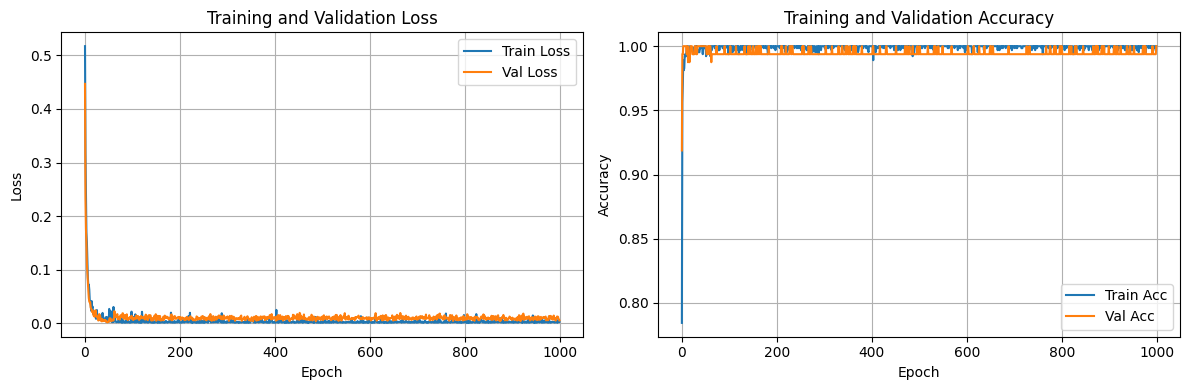


Model saved as '/workspaces/knot_mosaics/training/matrix_classifier_model.pth'


In [3]:
trained_model = main(epochs=1000)

In [4]:
from unseen_data import unseen_data_pairs


def predict_batch(model, matrices_list):
    model.eval()

    # Convert all matrices to a tensor batch
    batch = torch.FloatTensor(matrices_list).to(device)

    with torch.no_grad():
        outputs = model(batch).squeeze()
        predictions = (outputs > 0.5).int().tolist()
        confidences = [o.item() if p == 1 else 1-o.item()
                       for o, p in zip(outputs, predictions)]

    return predictions, confidences


# Extract just the matrices from unseen_data_pairs (which contains tuples of (matrix, label))
unseen_matrices = [matrix for matrix, label in unseen_data_pairs]
actual_labels = [label for matrix, label in unseen_data_pairs]

# Run predictions (assuming model is trained/loaded)
predictions, confidences = predict_batch(trained_model, unseen_matrices)

# Display results and track outliers
outliers = []
for i, (pred, conf, actual) in enumerate(zip(predictions, confidences, actual_labels)):
    print(f"Matrix {i+1}: Class {pred} (confidence: {conf:.2%})")
    if pred != actual:
        outliers.append({
            'index': i + 1,
            'predicted': pred,
            'actual': actual,
            'confidence': conf,
            'matrix': unseen_matrices[i]
        })

# Print outliers at the end
if outliers:
    print("\n" + "="*60)
    print("OUTLIERS - Predictions that don't match actual labels:")
    print("="*60)
    for outlier in outliers:
        print(f"Matrix {outlier['index']}: Predicted {outlier['predicted']}, "
              f"Actual {outlier['actual']} (confidence: {outlier['confidence']:.2%})")
        print(f"  Matrix data: {outlier['matrix']}")
else:
    print("\n" + "="*60)
    print("No outliers found - all predictions match actual labels!")
    print("="*60)

Matrix 1: Class 0 (confidence: 99.55%)
Matrix 2: Class 1 (confidence: 99.97%)
Matrix 3: Class 1 (confidence: 99.99%)
Matrix 4: Class 0 (confidence: 99.99%)
Matrix 5: Class 1 (confidence: 99.89%)
Matrix 6: Class 0 (confidence: 100.00%)
Matrix 7: Class 0 (confidence: 99.86%)
Matrix 8: Class 0 (confidence: 99.83%)
Matrix 9: Class 0 (confidence: 99.98%)
Matrix 10: Class 1 (confidence: 99.94%)
Matrix 11: Class 1 (confidence: 99.98%)
Matrix 12: Class 1 (confidence: 99.97%)
Matrix 13: Class 1 (confidence: 99.93%)
Matrix 14: Class 0 (confidence: 99.96%)
Matrix 15: Class 1 (confidence: 99.83%)
Matrix 16: Class 1 (confidence: 99.98%)
Matrix 17: Class 0 (confidence: 99.76%)
Matrix 18: Class 1 (confidence: 99.99%)
Matrix 19: Class 0 (confidence: 99.90%)
Matrix 20: Class 0 (confidence: 99.98%)
Matrix 21: Class 0 (confidence: 99.95%)
Matrix 22: Class 0 (confidence: 99.96%)
Matrix 23: Class 1 (confidence: 99.98%)
Matrix 24: Class 1 (confidence: 99.92%)
Matrix 25: Class 0 (confidence: 100.00%)
Matrix 